In [ ]:
#distance map PDB to HMM
from sequenceHandler import mapPDBToHMM
pdb_file = "1AAL.pdb"
chain_id = "A"
hmm_file = "PF00014.hmm"
hmm_file_2 = "None"        
output_map_file = "distance_map.txt"  

distance_map,map_index, alig_seq = mapPDBToHMM(pdb_file, chain_id, hmm_file, hmm_file_2, output_map_file, distType='all')
print(distance_map)
print(map_index)

FileNotFoundError: [Errno 2] No such file or directory: '1AAL.pdb'

In [2]:
import matplotlib.pyplot as plt

plt.figure()
plt.imshow(distance_map,cmap='coolwarm_r', origin='lower')
plt.colorbar(label="Distance")
plt.title("Distance Matrix Heatmap")
plt.show()

NameError: name 'distance_map' is not defined

<Figure size 640x480 with 0 Axes>

In [1]:
import os
from sequenceHandler import  stockholm2fasta,filterSequenceByGapContent,do_DCA,get_pfam_msa, extract_scop_ids
from sequenceHandler import mapPDBToHMM
import pickle
import requests
from pathlib import Path
import gzip
import shutil
import subprocess

import requests
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry
print(os.getpid())

5456


In [ ]:
def _make_session():
    session = requests.Session()
    retry = Retry(
        total=5,
        connect=5,
        read=5,
        status=5,
        backoff_factor=1.0,
        status_forcelist=(429, 500, 502, 503, 504),
        allowed_methods=frozenset(["GET"]),
        raise_on_status=False,
    )
    adapter = HTTPAdapter(max_retries=retry, pool_connections=1, pool_maxsize=1)
    session.mount("https://", adapter)
    session.headers.update(
        {
            "User-Agent": "Mozilla/5.0",
            "Connection": "close",
            "Accept": "*/*",
        }
    )
    return session

# with open("pfam_list.txt", "r") as f:
#     pfam_ids = [line.strip() for line in f]


# for pfam_id in pfam_ids:
#     data={}
#     print(pfam_id)
i=754
while True:
    try:
        i+=1
        data={}
        pfam_id=f"PF00{i}"
        print(pfam_id)

        # Get the MSA in Stockholm format and save it to a file
        msa = get_pfam_msa(pfam_id, kind="full")
        out_sto = f'MSA/msa_{pfam_id}.sto'
        with open(out_sto, "wb") as f:
            f.write(msa)

        # Extract the PDB ID from the Stockholm file and download the corresponding PDB file
        pdb_id = extract_scop_ids(out_sto)
        print(pdb_id)
        if not pdb_id==[]:
            resp = requests.get(url=f"https://files.rcsb.org/download/{pdb_id[0].upper()}.pdb")
            out_pdb = f'PDB/{pfam_id}.pdb'
            with open(out_pdb, "wb") as f:
                f.write(resp.content)

            # Get the HMM file for the Pfam family
            accession = pfam_id
            out_dir="HMM"
            accession = accession.strip().upper()

            if not accession.startswith("PF") or len(accession) != 7:
                raise ValueError("Expected a Pfam accession like PF00042")

            out_dir = Path(out_dir)
            out_dir.mkdir(parents=True, exist_ok=True)

            gz_path = out_dir / f"{accession}.hmm.gz"
            hmm_path = out_dir / f"{accession}.hmm"

            url = f"https://www.ebi.ac.uk/interpro/api/entry/pfam/{accession}?annotation=hmm"

            # First try pure Python requests with retries
            try:
                session = _make_session()
                with session.get(url, stream=True, timeout=(20, 120)) as r:
                    r.raise_for_status()
                    with open(gz_path, "wb") as f:
                        for chunk in r.iter_content(chunk_size=1024 * 64):
                            if chunk:
                                f.write(chunk)

            except requests.exceptions.SSLError:
                # Fallback: use curl if available, which often succeeds where requests/OpenSSL fails
                curl = shutil.which("curl") or shutil.which("curl.exe")
                if not curl:
                    raise RuntimeError(
                        "SSL error from requests, and curl was not found on PATH."
                    )

                cmd = [
                    curl,
                    "-L",
                    "--fail",
                    "--retry",
                    "5",
                    "--retry-delay",
                    "2",
                    "--connect-timeout",
                    "20",
                    "-o",
                    str(gz_path),
                    url,
                ]
                subprocess.run(cmd, check=True)

            # Decompress .gz -> .hmm
            with gzip.open(gz_path, "rb") as fin, open(hmm_path, "wb") as fout:
                shutil.copyfileobj(fin, fout)    

            #contanct map of the PDB and sequence
            from sequenceHandler import mapPDBToHMM
            pdb_file = f"PDB/{pfam_id}.pdb"
            chain_id = "A"
            hmm_file = f"HMM/{pfam_id}.hmm"
            hmm_file_2 = "None"        
            output_map_file = "None"  

            distance_map,map_index,aligned_sequence = mapPDBToHMM(pdb_file, chain_id, hmm_file, hmm_file_2, output_map_file, distType='all')

            gap_count=0
            for letter in aligned_sequence:
                if letter=="-":
                    gap_count+=1
            print(f"Gap percentage = {gap_count/len(aligned_sequence)*100}%")
            if gap_count>len(aligned_sequence)/2:
                raise ValueError("The number of gap is more than half of the sequence")


            # Takes the MSA of the family, convert Stockholm to FASTA, filter sequences by gap content, and perform DCA
            out_fasta= f'MSA/msa_{pfam_id}.fasta' 
            stockholm2fasta(out_sto,out_fasta)
            number_of_sequence=filterSequenceByGapContent(out_fasta, 0.2, out_fasta)
            print(number_of_sequence)

            if number_of_sequence<50000:
                score_map = do_DCA(out_fasta)
                

                data = {
                    'sequence': aligned_sequence,
                    'distance_map': distance_map,
                    'dca': score_map
                }

                with open(f"Data/data_{pfam_id}.pkl", "wb") as f:
                    pickle.dump(data, f)
            else:
                print("Too much sequences")
        else:
            print(f"No SCOP found for {pfam_id}, skipped")
    except:
        print(f"Some error occurred in the sequence {pfam_id}")

PF00755
['1ndi']


/home/fabio/miniconda3/envs/Internship/lib/python3.14/site-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain A is discontinuous at line 10065.
  warnings.warn(
/home/fabio/miniconda3/envs/Internship/lib/python3.14/site-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain B is discontinuous at line 10113.
  warnings.warn(
/home/fabio/miniconda3/envs/Internship/lib/python3.14/site-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain A is discontinuous at line 10161.
  warnings.warn(
/home/fabio/miniconda3/envs/Internship/lib/python3.14/site-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain B is discontinuous at line 10503.
  warnings.warn(


Gap percentage = 3.1358885017421603%
Original number of sequences  18146
Sequences after filtering :  13262
Filtered sequences saved to  MSA/msa_PF00755.fasta
13262
removing duplicate sequences... done: 13262 -> 12029
θ = 0.37582455338819776 threshold = 215.0
M = 12029 N = 574 Meff = 1089.354726863821
preprocessing took 2.698695535 seconds
site = 1	 pl = 0.1442	 time = 8.0096	exit status = FTOL_REACHED
site = 2	 pl = 0.0993	 time = 6.9734	exit status = FTOL_REACHED
site = 3	 pl = 0.2710	 time = 9.7820	exit status = FTOL_REACHED
site = 4	 pl = 0.1105	 time = 6.5658	exit status = FTOL_REACHED
site = 5	 pl = 0.6824	 time = 13.2945	exit status = FTOL_REACHED
site = 6	 pl = 0.1524	 time = 8.1333	exit status = FTOL_REACHED
site = 7	 pl = 0.7036	 time = 13.2106	exit status = FTOL_REACHED
site = 8	 pl = 0.6773	 time = 13.6908	exit status = FTOL_REACHED
site = 9	 pl = 0.1859	 time = 8.0489	exit status = FTOL_REACHED
site = 10	 pl = 0.4393	 time = 11.3990	exit status = FTOL_REACHED
site = 11	 pl

/home/fabio/miniconda3/envs/Internship/lib/python3.14/site-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain A is discontinuous at line 4401.
  warnings.warn(


Gap percentage = 0.6802721088435374%
Original number of sequences  9985
Sequences after filtering :  8441
Filtered sequences saved to  MSA/msa_PF00757.fasta
8441
removing duplicate sequences... done: 8441 -> 3701
θ = 0.3073827961125815 threshold = 45.0
M = 3701 N = 147 Meff = 395.8008996247493
preprocessing took 0.293618228 seconds
site = 1	 pl = 0.0263	 time = 0.3732	exit status = FTOL_REACHED
site = 2	 pl = 0.1596	 time = 0.4083	exit status = FTOL_REACHED
site = 3	 pl = 0.1540	 time = 0.4028	exit status = FTOL_REACHED
site = 4	 pl = 0.1119	 time = 0.3204	exit status = FTOL_REACHED
site = 5	 pl = 0.2784	 time = 0.4572	exit status = FTOL_REACHED
site = 6	 pl = 0.2748	 time = 0.4895	exit status = FTOL_REACHED
site = 7	 pl = 0.4429	 time = 0.4534	exit status = FTOL_REACHED
site = 8	 pl = 0.2420	 time = 0.4105	exit status = FTOL_REACHED
site = 9	 pl = 0.4242	 time = 0.4761	exit status = FTOL_REACHED
site = 10	 pl = 0.5867	 time = 0.5899	exit status = FTOL_REACHED
site = 11	 pl = 0.7476	 t

...

Gap percentage = 0.7092198581560284%
Original number of sequences  20222
Sequences after filtering :  16486
Filtered sequences saved to  MSA/msa_PF00790.fasta
16486
removing duplicate sequences... done: 16486 -> 9723
θ = 0.39705199999117785 threshold = 55.0
M = 9723 N = 141 Meff = 470.99534136831085
preprocessing took 1.025990674 seconds
site = 1	 pl = 0.0264	 time = 0.4844	exit status = FTOL_REACHED
site = 2	 pl = 0.1441	 time = 1.0518	exit status = FTOL_REACHED
site = 3	 pl = 0.3804	 time = 1.0568	exit status = FTOL_REACHED
site = 4	 pl = 0.7096	 time = 1.1298	exit status = FTOL_REACHED
site = 5	 pl = 0.6616	 time = 0.9944	exit status = FTOL_REACHED
site = 6	 pl = 0.8526	 time = 1.1606	exit status = FTOL_REACHED
site = 7	 pl = 0.5855	 time = 1.2650	exit status = FTOL_REACHED
site = 8	 pl = 0.7533	 time = 1.1811	exit status = FTOL_REACHED
site = 9	 pl = 1.0436	 time = 1.2497	exit status = FTOL_REACHED
site = 10	 pl = 0.9487	 time = 1.1935	exit status = FTOL_REACHED
site = 11	 pl = 0.4

/home/fabio/miniconda3/envs/Internship/lib/python3.14/site-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain A is discontinuous at line 11142.
  warnings.warn(
/home/fabio/miniconda3/envs/Internship/lib/python3.14/site-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain B is discontinuous at line 11158.
  warnings.warn(
/home/fabio/miniconda3/envs/Internship/lib/python3.14/site-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain C is discontinuous at line 11174.
  warnings.warn(
/home/fabio/miniconda3/envs/Internship/lib/python3.14/site-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain D is discontinuous at line 11190.
  warnings.warn(
/home/fabio/miniconda3/envs/Internship/lib/python3.14/site-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain A is discontinuous at line 11206.
  warnings.warn(
/home/fabio/miniconda3/envs/Internship/lib/py

Gap percentage = 5.185185185185185%
Original number of sequences  17760
Sequences after filtering :  17086
Filtered sequences saved to  MSA/msa_PF00793.fasta
17086
removing duplicate sequences... done: 17086 -> 16753
θ = 0.3778235726249964 threshold = 102.0
M = 16753 N = 270 Meff = 248.66929360710176
preprocessing took 3.144809535 seconds
site = 1	 pl = 0.0133	 time = 1.9571	exit status = FTOL_REACHED
site = 2	 pl = 0.0421	 time = 7.3716	exit status = FTOL_REACHED
site = 3	 pl = 0.0820	 time = 3.2035	exit status = FTOL_REACHED
site = 4	 pl = 0.0905	 time = 4.0152	exit status = FTOL_REACHED
site = 5	 pl = 0.1536	 time = 4.1175	exit status = FTOL_REACHED
site = 6	 pl = 0.1518	 time = 4.8819	exit status = FTOL_REACHED
site = 7	 pl = 0.1974	 time = 4.4453	exit status = FTOL_REACHED
site = 8	 pl = 0.3586	 time = 4.9807	exit status = FTOL_REACHED
site = 9	 pl = 0.5985	 time = 5.9777	exit status = FTOL_REACHED
site = 10	 pl = 0.4210	 time = 5.1126	exit status = FTOL_REACHED
site = 11	 pl = 0.

/home/fabio/miniconda3/envs/Internship/lib/python3.14/site-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain A is discontinuous at line 7267.
  warnings.warn(
/home/fabio/miniconda3/envs/Internship/lib/python3.14/site-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain B is discontinuous at line 7287.
  warnings.warn(
/home/fabio/miniconda3/envs/Internship/lib/python3.14/site-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain A is discontinuous at line 7294.
  warnings.warn(
/home/fabio/miniconda3/envs/Internship/lib/python3.14/site-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain B is discontinuous at line 7394.
  warnings.warn(


Gap percentage = 2.734375%
Original number of sequences  60994
Sequences after filtering :  48676
Filtered sequences saved to  MSA/msa_PF00795.fasta
48676
removing duplicate sequences... done: 48676 -> 46767
θ = 0.5 threshold = 128.0
M = 46767 N = 256 Meff = 2287.755408212384
preprocessing took 19.597186195 seconds
site = 1	 pl = 0.6553	 time = 15.4624	exit status = FTOL_REACHED
site = 2	 pl = 0.7381	 time = 16.8457	exit status = FTOL_REACHED
site = 3	 pl = 0.5831	 time = 15.1068	exit status = FTOL_REACHED
site = 4	 pl = 0.9829	 time = 16.4189	exit status = FTOL_REACHED
site = 5	 pl = 0.9677	 time = 16.0111	exit status = FTOL_REACHED
site = 6	 pl = 0.3214	 time = 10.5124	exit status = FTOL_REACHED
site = 7	 pl = 1.2486	 time = 16.1901	exit status = FTOL_REACHED
site = 8	 pl = 1.2556	 time = 14.1734	exit status = FTOL_REACHED
site = 9	 pl = 1.2240	 time = 14.8610	exit status = FTOL_REACHED
site = 10	 pl = 1.5291	 time = 14.7988	exit status = FTOL_REACHED
site = 11	 pl = 1.4222	 time = 1

In [1]:
import pickle

pfam_id = "PF00007"
with open(f"Data/data_{pfam_id}.pkl", "rb") as f:
    loaded = pickle.load(f)

sequence=loaded['sequence'] 
distance_map=loaded['distance_map']
contact_map_DCA=loaded['dca']

In [2]:
print(sequence)

['-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', 'L', 'Q', 'C', 'M', 'G', 'C', 'C', 'F', 'S', 'R', 'P', 'T', 'P', 'L', 'R', 'S', 'K', 'K', 'T', 'M', 'L', 'V', 'Q', 'K', 'N', 'V', 'T', 'S', 'E', 'S', '-', '-', '-', '-', 'T', 'C', 'C', 'V', 'A', 'K', 'S', 'Y', 'N', 'R', 'V', 'T', 'V', 'G', 'F', 'K', 'V', 'E', 'N', 'H', 'T', 'A', 'C', 'H', 'C', 'S', 'T', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-']


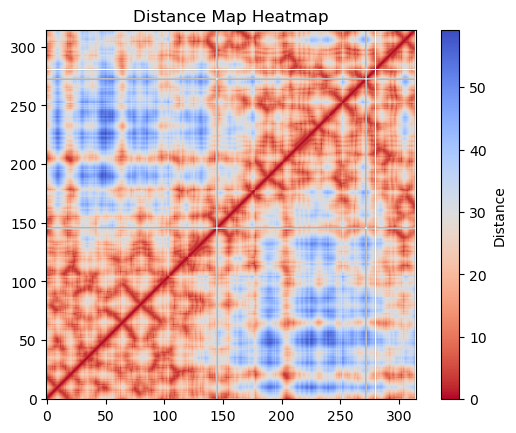

In [16]:
import matplotlib.pyplot as plt

plt.figure()
plt.imshow(distance_map,cmap='coolwarm_r', origin='lower')
plt.colorbar(label="Distance")
plt.title("Distance Map Heatmap")
plt.show()

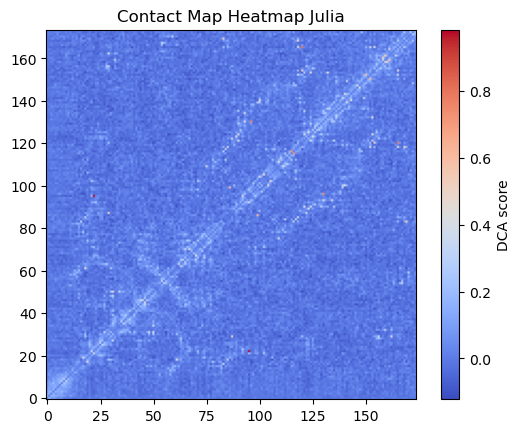

In [9]:
plt.figure()
plt.imshow(contact_map_DCA,cmap='coolwarm', origin='lower')
plt.colorbar(label="DCA score")
plt.title("Contact Map Heatmap Julia")
plt.show()

In [1]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt

folder_path = "Data"

total_distances = []
total_scrores = []

for file in os.listdir(folder_path):
    if file.endswith(".pkl"):
        full_path = os.path.join(folder_path, file)
        
        with open(full_path, "rb") as f:
            loaded = pickle.load(f)

        sequence=loaded['sequence'] 
        #print(sequence)



        distance_map=loaded['distance_map']

        #Extract unique distances (no diagonal, no duplicates)
        distances = distance_map[np.triu_indices_from(distance_map, k=1)]

        # Remove invalid values
        distances = distances[np.isfinite(distances)]
        total_distances.extend(distances)
        # # Plot
        # plt.figure()
        # plt.hist(distances, bins=50, density=True)
        # plt.xlabel("Distance (Å)")
        # plt.ylabel("Density")
        # plt.title("Distance Distribution")
        # plt.show()



        contact_map_DCA=loaded['dca']

        # Extract unique distances (no diagonal, no duplicates)
        distances = contact_map_DCA[np.triu_indices_from(contact_map_DCA, k=1)]
        total_scrores.extend(distances) 
        # # Plot
        # plt.figure()
        # plt.hist(distances, bins=50, density=True)
        # plt.xlabel("DCA Score")
        # plt.ylabel("Density")
        # plt.title("DCA Score Distribution")
        # plt.show()




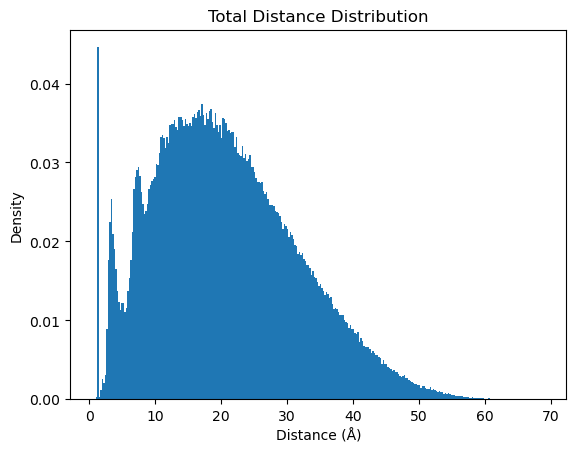

In [2]:
plt.figure()
plt.hist(total_distances, bins=300, density=True)
plt.xlabel("Distance (Å)")
plt.ylabel("Density")
plt.title("Total Distance Distribution")
plt.show()

20.844407489133516 10.825315429915898


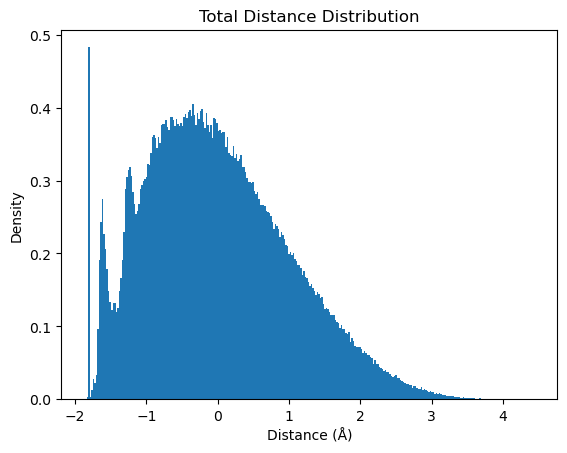

In [3]:
m=min(total_distances)
mean=np.mean(total_distances)
sigma=np.std(total_distances)
print(mean, sigma) 
plt.figure()
plt.hist((np.array(total_distances)-mean)/sigma, bins=300, density=True)
plt.xlabel("Distance (Å)")
plt.ylabel("Density")
plt.title("Total Distance Distribution")
plt.show()

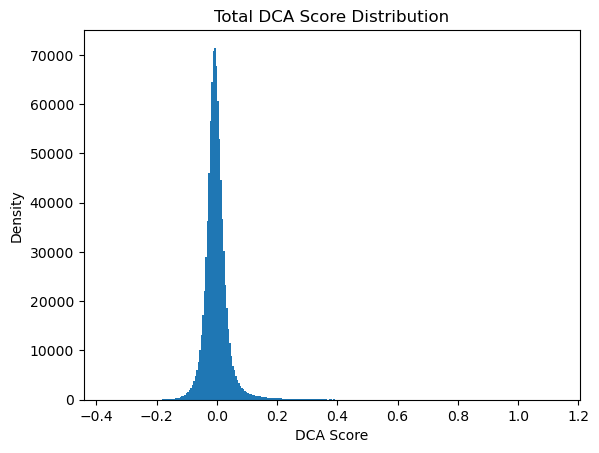

In [4]:
plt.figure()
#t_d = [d for d in total_distances if d > 1.34] 
plt.hist(np.log(np.array(total_scrores)+1), bins=300, density=False)
plt.xlabel("DCA Score")
plt.ylabel("Density")
plt.title("Total DCA Score Distribution")
plt.show()